In [1]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


from xgboost import XGBClassifier
import joblib

In [2]:
df = pd.read_csv(r"C:\Users\bijar\Desktop\dataset\Obfuscated-MalMem2022.csv")


print(df.shape)
df.head()

(58596, 57)


,Category,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,...,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class
0,Benign,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,...,221,26,24,116,0,121,87,0,8,Benign
1,Benign,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,...,222,26,24,118,0,122,87,0,8,Benign
2,Benign,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,...,222,26,27,118,0,120,88,0,8,Benign
3,Benign,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,...,222,26,27,118,0,120,88,0,8,Benign
4,Benign,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,...,222,26,24,118,0,124,87,0,8,Benign


In [3]:
df["Category"].value_counts()

Category
Benign                                                                                     29298
Trojan-Zeus-0e410a79d87fecfd37f7831e4682ada7a2d480f0759a71fa3893a5500faf4070-1.raw             2
Trojan-Zeus-0e410a79d87fecfd37f7831e4682ada7a2d480f0759a71fa3893a5500faf4070-10.raw            2
Trojan-Zeus-0e410a79d87fecfd37f7831e4682ada7a2d480f0759a71fa3893a5500faf4070-2.raw             2
Trojan-Zeus-0e410a79d87fecfd37f7831e4682ada7a2d480f0759a71fa3893a5500faf4070-3.raw             2
                                                                                           ...  
Ransomware-Ako-00a2c6bab1e53f679cdd4fdc772cd291928c109b9b747652639a1700d844f719-3.raw          1
Ransomware-Ako-00a2c6bab1e53f679cdd4fdc772cd291928c109b9b747652639a1700d844f719-2.raw          1
Ransomware-Ako-00a2c6bab1e53f679cdd4fdc772cd291928c109b9b747652639a1700d844f719-10.raw         1
Ransomware-Ako-00a2c6bab1e53f679cdd4fdc772cd291928c109b9b747652639a1700d844f719-1.raw          1
Ransomware-Shade-955d

In [4]:
# Convert to binary classification
df["Category"] = df["Category"].apply(
lambda x: "Benign" if x == "Benign" else "Ransomware"
)
# Reset index
df = df.reset_index(drop=True)
# Create binary labels
y = df["Category"].map({
"Benign": 0,
"Ransomware": 1
})
# Verify
print("NaN labels:", y.isna().sum())
print(y.value_counts())

NaN labels: 0
Category
0    29298
1    29298
Name: count, dtype: int64


In [5]:
X = pd.DataFrame()

In [6]:
# ===== PROCESS BEHAVIOR =====
X["process_count"] = df["pslist.nproc"]
X["parent_process_count"] = df["pslist.nppid"]
X["avg_threads"] = df["pslist.avg_threads"]
X["avg_handlers"] = df["pslist.avg_handlers"]
# ===== DLL / IMAGE LOAD =====
X["dll_count"] = df["dlllist.ndlls"]
X["dlls_per_process"] = df["dlllist.avg_dlls_per_proc"]
# ===== HANDLE ACTIVITY =====
X["handles_total"] = df["handles.nhandles"]
X["handles_avg"] = df["handles.avg_handles_per_proc"]
# ===== SERVICES =====
X["service_count"] = df["svcscan.nservices"]
X["process_services"] = df["svcscan.process_services"]
# ===== MALICIOUS MEMORY INDICATORS =====
X["mal_injections"] = df["malfind.ninjections"]
X["mal_commit_charge"] = df["malfind.commitCharge"]
# ===== AGGREGATED FEATURES =====
X["total_activity"] = X.sum(axis=1)
X["process_density"] = X["process_count"] / (X["total_activity"] + 1)
X["handle_density"] = X["handles_total"] / (X["process_count"] + 1)

In [7]:
print(X.shape)
print(y.shape)


(58596, 15)
(58596,)


In [8]:
from sklearn.preprocessing import StandardScaler

# Save column names
cols = X.columns

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame with correct names
X = pd.DataFrame(X_scaled, columns=cols)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(46876, 15) (11720, 15)


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


rf = RandomForestClassifier(
n_estimators=200,
random_state=42,
n_jobs=-1
)


rf.fit(X_train, y_train)


rf_pred = rf.predict(X_test)


print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.999914675767918
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5860
           1       1.00      1.00      1.00      5860

    accuracy                           1.00     11720
   macro avg       1.00      1.00      1.00     11720
weighted avg       1.00      1.00      1.00     11720



In [11]:
from xgboost import XGBClassifier


xgb = XGBClassifier(
n_estimators=200,
max_depth=6,
learning_rate=0.1,
eval_metric="logloss"
)


xgb.fit(X_train, y_train)


xgb_pred = xgb.predict(X_test)


print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.9998293515358362
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5860
           1       1.00      1.00      1.00      5860

    accuracy                           1.00     11720
   macro avg       1.00      1.00      1.00     11720
weighted avg       1.00      1.00      1.00     11720



In [12]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(xgb, "xgboost_model.pkl")

print(" Models saved successfully")

 Models saved successfully


In [13]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd


# Same for y (important sometimes)
if not isinstance(y, pd.Series):
    y = pd.Series(y)

kf = StratifiedKFold(n_splits=5)

# ---- Random Forest CV ----
rf_scores = []
for train_idx, test_idx in kf.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    rf_cv = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf_cv.fit(X_tr, y_tr)
    rf_scores.append(accuracy_score(y_te, rf_cv.predict(X_te)))

print("RF CV Scores:", rf_scores)
print("RF Mean:", round(np.mean(rf_scores), 4))
print("RF Std:", round(np.std(rf_scores), 4))

# ---- XGBoost CV ----
xgb_scores = []
for train_idx, test_idx in kf.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    xgb_cv = XGBClassifier(n_estimators=200, max_depth=6,
                           learning_rate=0.1, eval_metric="logloss")
    xgb_cv.fit(X_tr, y_tr)
    xgb_scores.append(accuracy_score(y_te, xgb_cv.predict(X_te)))

print("\nXGB CV Scores:", xgb_scores)
print("XGB Mean:", round(np.mean(xgb_scores), 4))
print("XGB Std:", round(np.std(xgb_scores), 4))

RF CV Scores: [0.9997440273037542, 1.0, 0.9951361037631197, 0.999061353357795, 1.0]
RF Mean: 0.9988
RF Std: 0.0019

XGB CV Scores: [0.9997440273037542, 1.0, 0.9951361037631197, 0.9988053588190119, 1.0]
XGB Mean: 0.9987
XGB Std: 0.0019


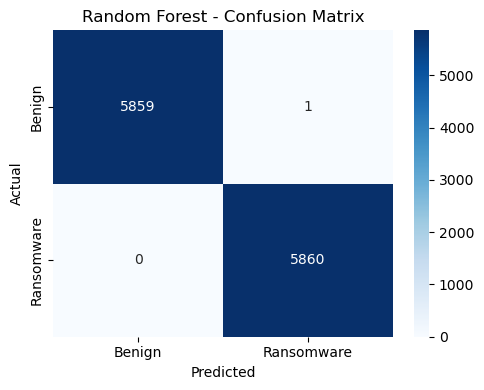

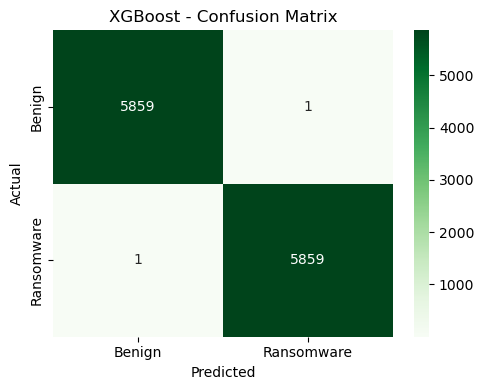

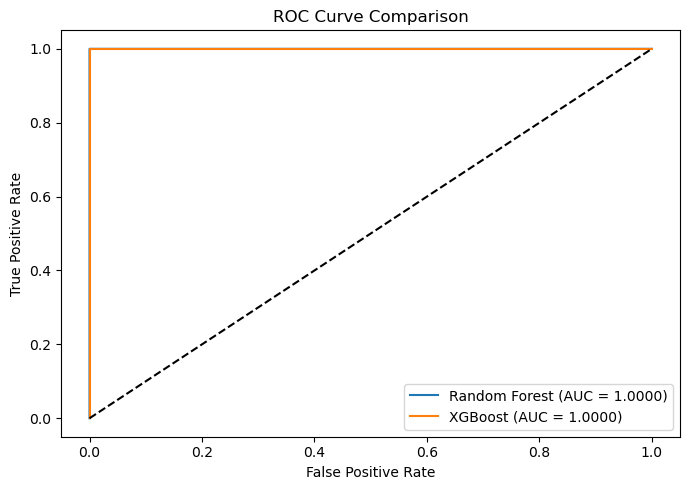

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# ---- Confusion Matrix - Random Forest ----
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign","Ransomware"],
            yticklabels=["Benign","Ransomware"])
plt.title("Random Forest - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# ---- Confusion Matrix - XGBoost ----
cm_xgb = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Benign","Ransomware"],
            yticklabels=["Benign","Ransomware"])
plt.title("XGBoost - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# ---- ROC Curve - Both Models ----
rf_proba  = rf.predict_proba(X_test)[:,1]
xgb_proba = xgb.predict_proba(X_test)[:,1]

rf_fpr,  rf_tpr,  _ = roc_curve(y_test, rf_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)

rf_auc  = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)

plt.figure(figsize=(7,5))
plt.plot(rf_fpr,  rf_tpr,  label=f"Random Forest (AUC = {rf_auc:.4f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.4f})")
plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


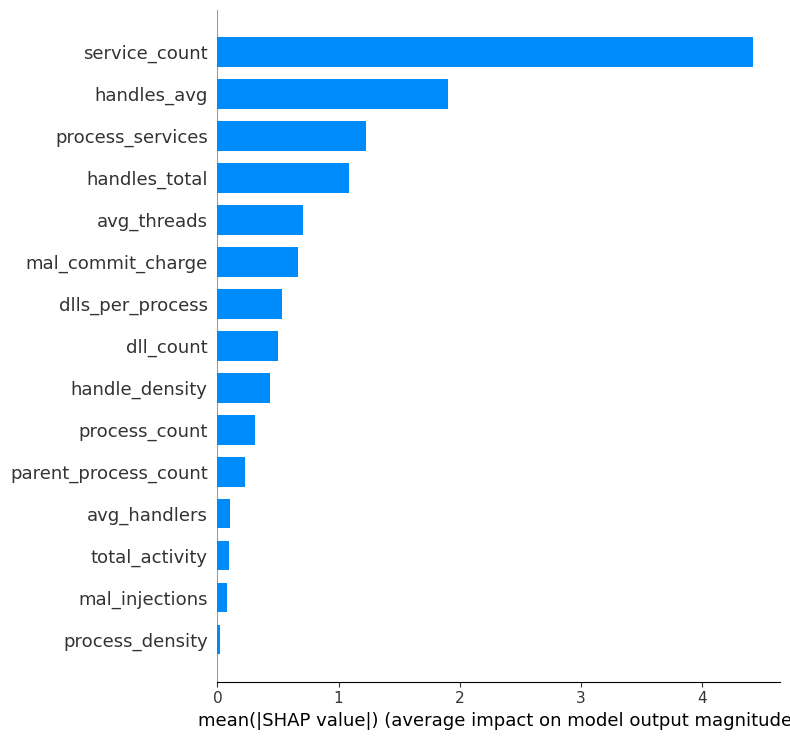

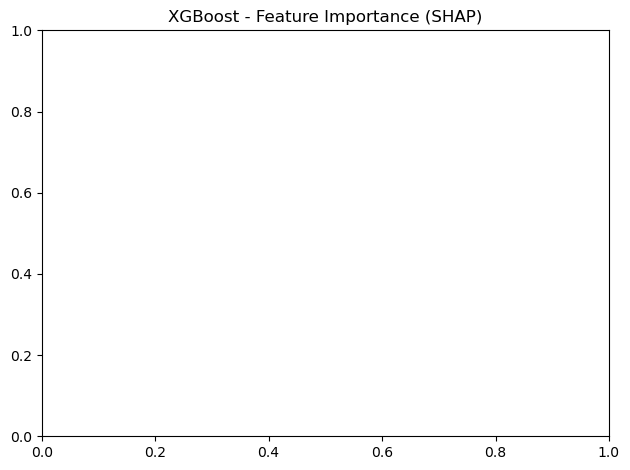

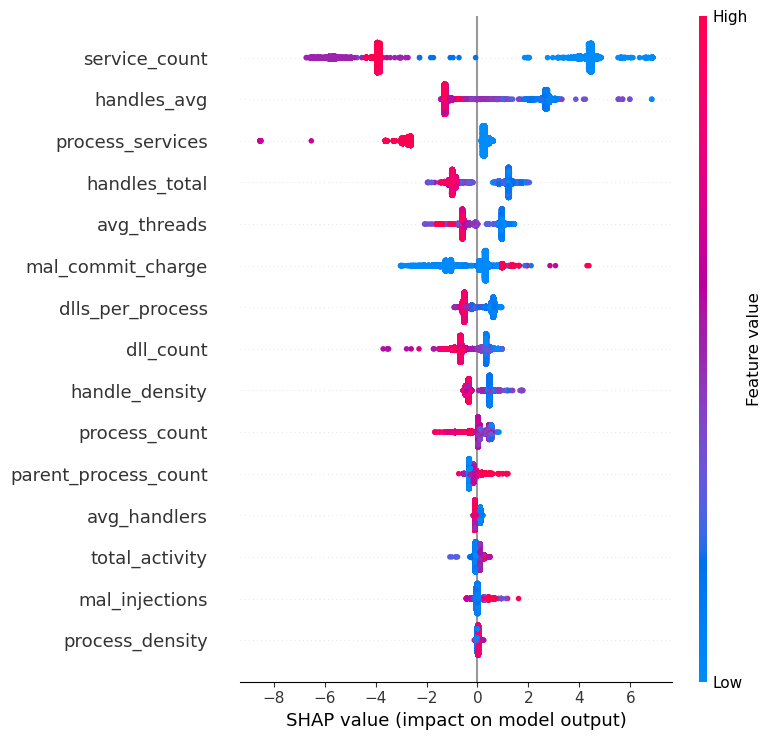

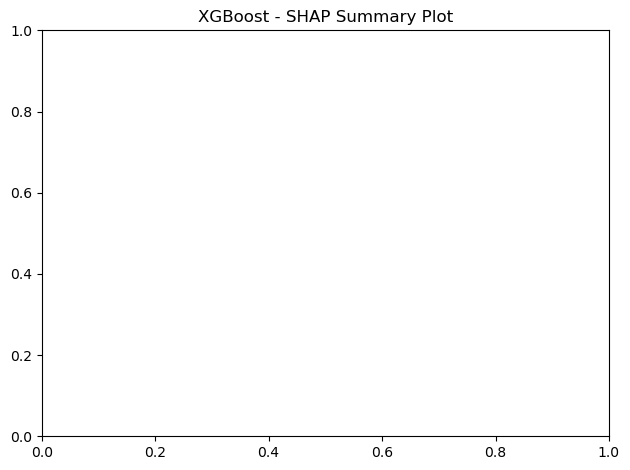

In [16]:
import shap

# ---- SHAP for XGBoost ----
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Plot 1 - Feature Importance Summary
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  feature_names=X.columns.tolist())
plt.title("XGBoost - Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

# Plot 2 - Detailed SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist())
plt.title("XGBoost - SHAP Summary Plot")
plt.tight_layout()
plt.show()

In [17]:
from sklearn.ensemble import IsolationForest

# Train on benign samples only
X_benign = X[y == 0]

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)

iso_forest.fit(X_benign)

# Save model
joblib.dump(iso_forest, "isolation_forest_model.pkl")
print("Isolation Forest trained and saved")

Isolation Forest trained and saved


In [18]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")

['feature_columns.pkl']

In [19]:
print(len(X.columns))

15


In [20]:
joblib.dump(list(X.columns), "feature_columns.pkl")
print(X.columns)

Index(['process_count', 'parent_process_count', 'avg_threads', 'avg_handlers',
       'dll_count', 'dlls_per_process', 'handles_total', 'handles_avg',
       'service_count', 'process_services', 'mal_injections',
       'mal_commit_charge', 'total_activity', 'process_density',
       'handle_density'],
      dtype='object')


In [21]:
# ================= SAVE ALL IMPORTANT GRAPHS =================
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Create folder
if not os.path.exists("images"):
    os.makedirs("images")

# -------- CONFUSION MATRIX - RANDOM FOREST --------
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign","Ransomware"],
            yticklabels=["Benign","Ransomware"])
plt.title("Random Forest Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()

plt.savefig("images/rf_confusion_matrix.png")
plt.close()


# -------- CONFUSION MATRIX - XGBOOST --------
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Benign","Ransomware"],
            yticklabels=["Benign","Ransomware"])
plt.title("XGBoost Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()

plt.savefig("images/xgb_confusion_matrix.png")
plt.close()


# -------- ROC CURVE --------
rf_proba  = rf.predict_proba(X_test)[:,1]
xgb_proba = xgb.predict_proba(X_test)[:,1]

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)

rf_auc  = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)

plt.figure(figsize=(7,5))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_auc:.3f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC={xgb_auc:.3f})")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()

plt.savefig("images/roc_curve.png")
plt.close()


# -------- SHAP FEATURE IMPORTANCE --------
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.savefig("images/shap_bar.png")
plt.close()

# Detailed plot (optional)
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig("images/shap_summary.png")
plt.close()


print("\n All graphs saved in 'images' folder successfully!")


 All graphs saved in 'images' folder successfully!


In [22]:
import os
print("Saved at:", os.path.abspath("images"))


Saved at: C:\Users\bijar\anaconda_projects\a56f1486-ef09-4ee6-95e9-5e7441c7b54e\images
